In [56]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [57]:
stock=pd.read_csv("stock_market_raw.csv")
print(stock.head(),"\n\n\n")
print(stock.describe(),"\n\n\n")
print(stock.shape,"\n\n\n")
print(stock.info(),"\n\n\n")

  ticker      sector        date     open     high      low    close  \
0  GOOGL  Technology  2021-02-01  3012.49  3059.21  3010.74  3049.82   
1    JNJ  Healthcare  2021-09-01   139.77   139.88   135.07   137.25   
2    JPM     Finance  2021-07-16   196.40   200.71   195.36   198.92   
3   AMZN  E-Commerce  2021-10-15  3937.66  3988.52  3936.09  3940.38   
4    JNJ  Healthcare  2021-09-28   125.96   126.36   122.38   123.82   

       volume  daily_return_pct  pct_change     ma_7    ma_30    ma_50    rsi  \
0  44229925.0            1.2392      1.8998      NaN  3049.82  3049.82  50.39   
1  57603424.0           -1.8030     -1.6834   137.69   148.86   155.74  51.68   
2  75133357.0            1.2831      2.3304   189.96   178.73   170.64  67.75   
3  61647398.0            0.0691      0.1230  4001.49  3994.66  3961.19  42.77   
4  73525480.0           -1.6990     -1.7068   125.01   134.06   142.12  36.86   

    macd  volatility_10d signal  next_day_return  
0    NaN         37.6418   Se

In [58]:
stock.isnull().sum()

ticker               0
sector               0
date                 5
open                 0
high                 0
low                  0
close               34
volume              35
daily_return_pct     0
pct_change           0
ma_7                35
ma_30                0
ma_50                0
rsi                 36
macd                37
volatility_10d       0
signal               0
next_day_return      0
dtype: int64

In [59]:
stock["close"]=pd.to_numeric(stock["close"],errors="coerce")
stock["volume"]=pd.to_numeric(stock["volume"],errors="coerce")
stock["close"]=stock["close"].fillna(stock["close"].median())
stock["volume"]=stock["volume"].fillna(stock["volume"].median())
stock["ma_7"]=stock["ma_7"].fillna(stock["ma_7"].median())
stock["rsi"]=stock["rsi"].fillna(stock["rsi"].median())
stock["macd"]=stock["macd"].fillna(stock["macd"].median())
stock["date"]=stock["date"].fillna("Unknown")

In [60]:
def fix_outliers(df,column,min_value=0):
    Q1= df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower=max(Q1 - 1.5*IQR,min_value)
    maximum=Q3 +  1.5*IQR
    df[column]=df[column].clip(lower,maximum)
    return df

all_feature=['open', 'high', 'low',
     'ma_7', 'ma_30', 'ma_50',
    'rsi']

for col in all_feature:
    stock=fix_outliers(stock,col)
stock = fix_outliers(stock, 'close', min_value=1)
stock = fix_outliers(stock, 'volume', min_value=1000)
stock = fix_outliers(stock, 'volatility_10d', min_value=0.01)


all_negative= ['macd', 'daily_return_pct', 'pct_change', 'next_day_return']


for sea in all_negative:
    stock=fix_outliers(stock,sea,min_value=-9999)

In [61]:
stock.describe()

,open,high,low,close,volume,daily_return_pct,pct_change,ma_7,ma_30,ma_50,rsi,macd,volatility_10d,next_day_return
count,2128.000000,2128.000000,2128.000000,2128.000000,2.128000e+03,2128.000000,2128.000000,2128.000000,2128.000000,2128.000000,2128.000000,2128.000000,2128.000000,2128.000000
mean,981.405982,992.739704,970.306184,482.555240,4.247981e+07,0.007804,0.010649,483.709240,978.537627,974.731941,50.261248,0.727067,14.104639,-0.050778
std,1319.567552,1332.744362,1306.667497,446.980845,2.160302e+07,1.890627,1.998895,446.956799,1312.357736,1304.885827,10.532167,11.075473,16.087114,2.684129
min,49.120000,52.660000,43.720000,1.000000,1.000000e+03,-4.398713,-4.734850,58.130000,76.120000,82.510000,21.410000,-19.588750,0.010000,-5.806975
25%,147.002500,149.552500,144.450000,147.300000,2.426919e+07,-1.083150,-1.195975,148.682500,146.155000,147.302500,42.717500,-4.427500,2.832450,-1.468150
50%,258.475000,260.265000,256.250000,257.315000,4.266100e+07,-0.022450,0.000000,271.570000,250.155000,246.625000,50.490000,0.000000,6.334250,-0.105150
75%,2424.410000,2460.442500,2401.080000,583.420000,6.024587e+07,1.127225,1.163275,585.252500,2557.460000,2590.347500,57.872500,5.680000,20.877125,1.424400
max,4304.310000,4372.480000,4282.330000,1237.600000,1.142109e+08,4.442787,4.702150,1240.107500,4204.620000,4120.750000,80.605000,20.841250,47.944137,5.763225


In [62]:
stock=stock.drop_duplicates()

In [63]:
stock.dtypes

ticker               object
sector               object
date                 object
open                float64
high                float64
low                 float64
close               float64
volume              float64
daily_return_pct    float64
pct_change          float64
ma_7                float64
ma_30               float64
ma_50               float64
rsi                 float64
macd                float64
volatility_10d      float64
signal               object
next_day_return     float64
dtype: object

In [66]:
stock["volume"]=stock["volume"].astype(int)
stock["date"]=pd.to_datetime(stock["date"],errors="coerce")

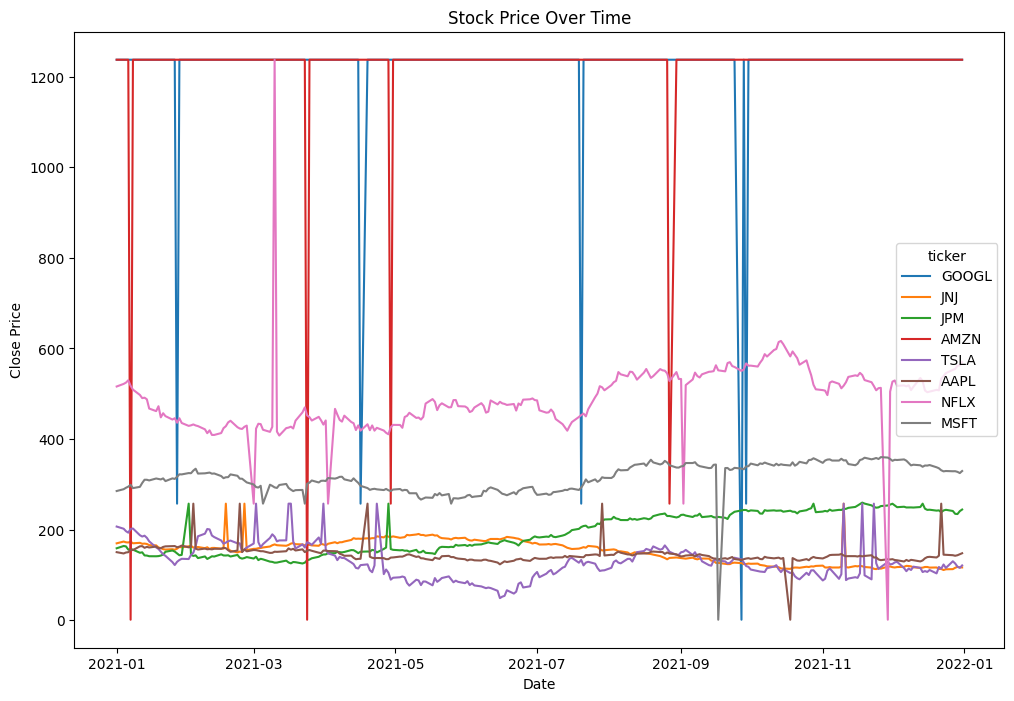

In [72]:
plt.figure(figsize=(12,8))
sns.lineplot(x=stock["date"],y=stock["close"],hue=stock["ticker"])
plt.title('Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

/var/folders/6m/qm4yytdd1ql5xd4tkcvf2d880000gn/T/ipykernel_751/2153477951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stock["ticker"], y=stock["volume"], palette='Set2')


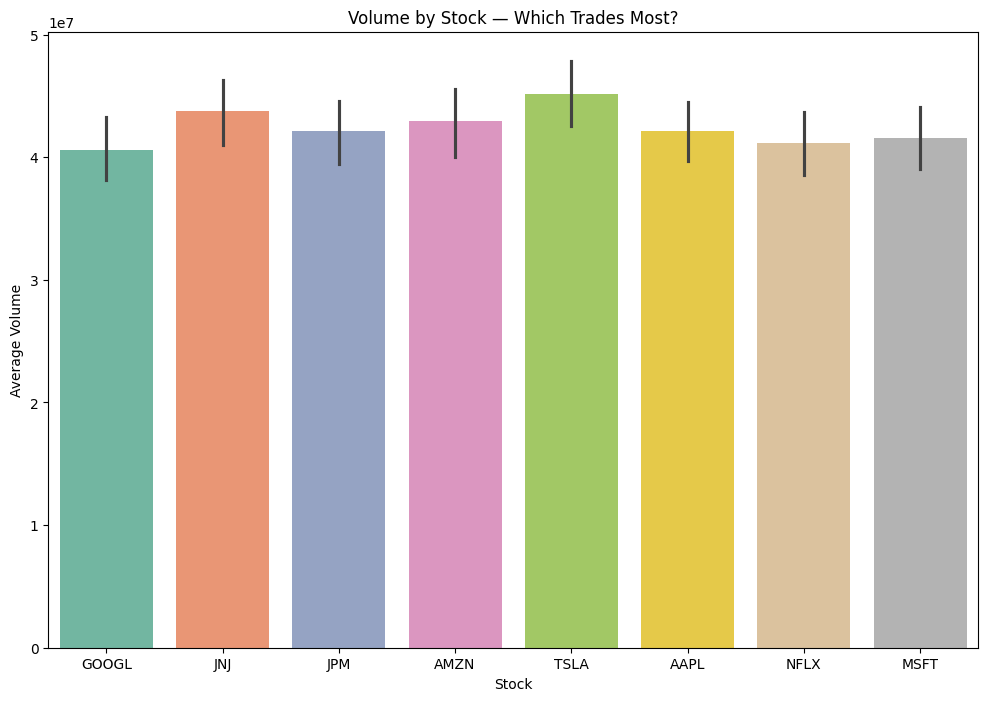

In [76]:
plt.figure(figsize=(12,8))
sns.barplot(x=stock["ticker"], y=stock["volume"], palette='Set2')
plt.title('Volume by Stock — Which Trades Most?')
plt.xlabel('Stock')
plt.ylabel('Average Volume')
plt.show()

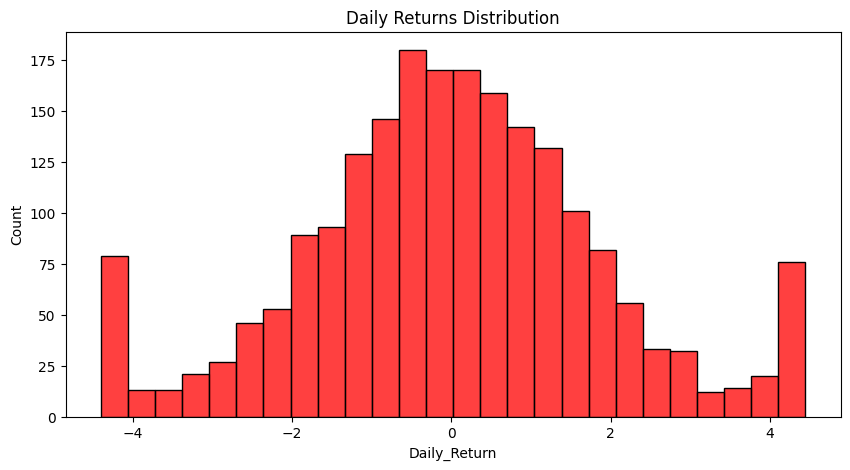

In [88]:
plt.figure(figsize=(10,5))
sns.histplot(stock["daily_return_pct"],color="red")
plt.title("Daily Returns Distribution")
plt.xlabel("Daily_Return")
plt.ylabel("Count")
plt.show()

/var/folders/6m/qm4yytdd1ql5xd4tkcvf2d880000gn/T/ipykernel_751/1524716551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=stock["signal"],palette="Set2",)


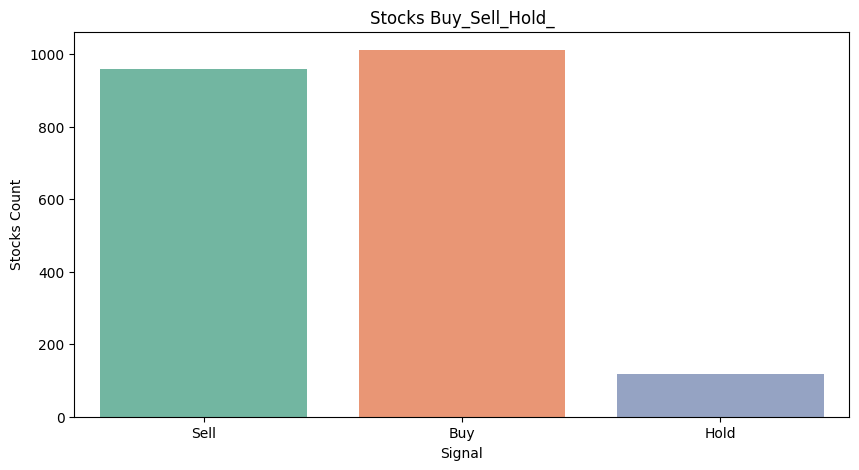

In [93]:
plt.figure(figsize=(10,5))
sns.countplot(x=stock["signal"],palette="Set2",)
plt.title("Stocks Buy_Sell_Hold_")
plt.xlabel("Signal")
plt.ylabel("Stocks Count")
plt.show()

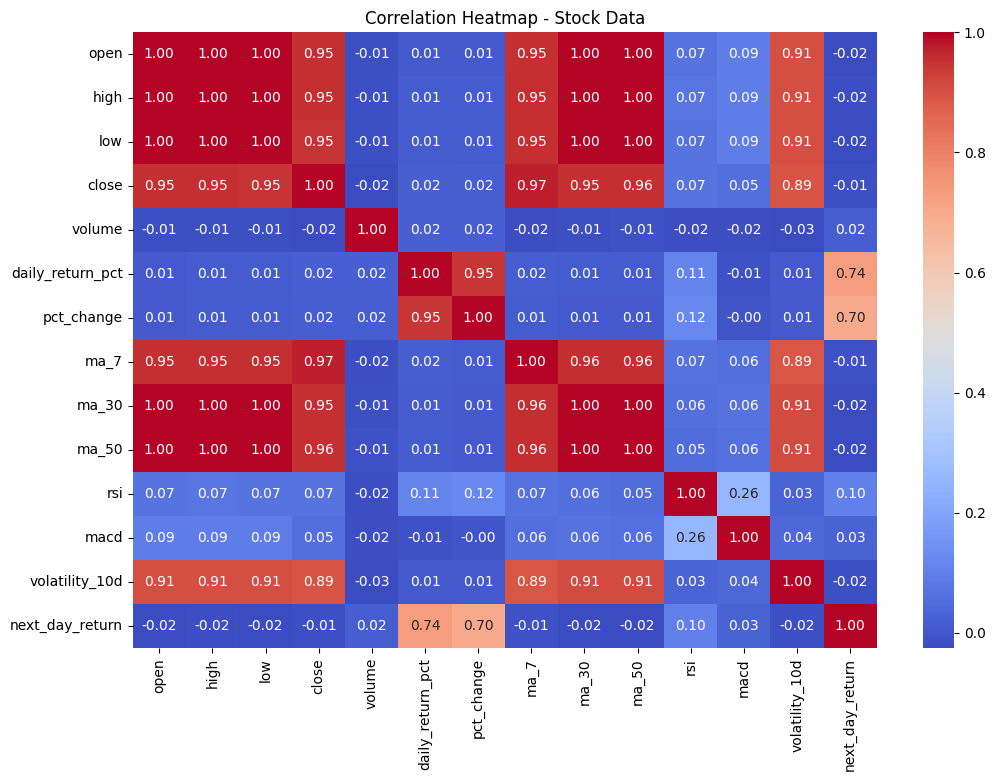

In [97]:
plt.figure(figsize=(12,8))
sns.heatmap(stock.corr(numeric_only=True),
            annot=True,
            fmt=".2f",
            cmap="coolwarm"
           )
plt.title('Correlation Heatmap - Stock Data')
plt.show()

In [98]:
stock.to_csv("stock_cleaned.csv", index=False)